In [10]:
!pip install librosa pandas scikit-learn matplotlib seaborn

In [11]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def extract_features(file):
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')    
    mfccs = np.mean(
        librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )
    return mfccs

In [13]:
features = []
labels = []

dataset_path = "../data"
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        
        if file.endswith(".wav"):
            
            path = os.path.join(root, file)
            
            emotion = file.split("-")[2]
            
            data = extract_features(path)
            features.append(data)
            labels.append(emotion)

In [14]:
from sklearn.model_selection import train_test_split

X = np.array(features)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
print(len(features))
print(len(labels))

In [ ]:
import os

print(os.listdir())

In [ ]:
print(os.listdir("data"))

In [ ]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

In [ ]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

In [ ]:
!pip install resampy

In [ ]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
!{sys.executable} -m pip install resampy

In [ ]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

In [1]:
import os
import librosa
import numpy as np
import pandas as pd

In [3]:
def extract_features(file):

    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')

    mfccs = np.mean(
        librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )

    return mfccs

In [4]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

Total samples: 1440


In [5]:
X = np.array(features)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1440, 40)
(1440,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1152, 40)
(288, 40)


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5902777777777778


In [10]:
import pickle

pickle.dump(model, open("../models/emotion_model.pkl", "wb"))

print("Model saved successfully")

Model saved successfully


In [11]:
emotion_dict = {
"01": "Neutral",
"02": "Calm",
"03": "Happy",
"04": "Sad",
"05": "Angry",
"06": "Fear",
"07": "Disgust",
"08": "Surprise"
}

for i in range(10):
    print("Predicted:", emotion_dict[y_pred[i]])

Predicted: Disgust
Predicted: Calm
Predicted: Fear
Predicted: Calm
Predicted: Disgust
Predicted: Neutral
Predicted: Calm
Predicted: Fear
Predicted: Disgust
Predicted: Sad


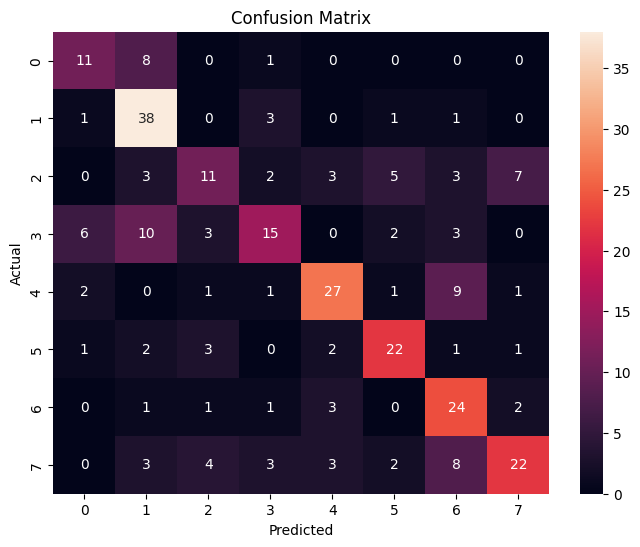

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          01       0.52      0.55      0.54        20
          02       0.58      0.86      0.70        44
          03       0.48      0.32      0.39        34
          04       0.58      0.38      0.46        39
          05       0.71      0.64      0.68        42
          06       0.67      0.69      0.68        32
          07       0.49      0.75      0.59        32
          08       0.67      0.49      0.56        45

    accuracy                           0.59       288
   macro avg       0.59      0.59      0.57       288
weighted avg       0.60      0.59      0.58       288



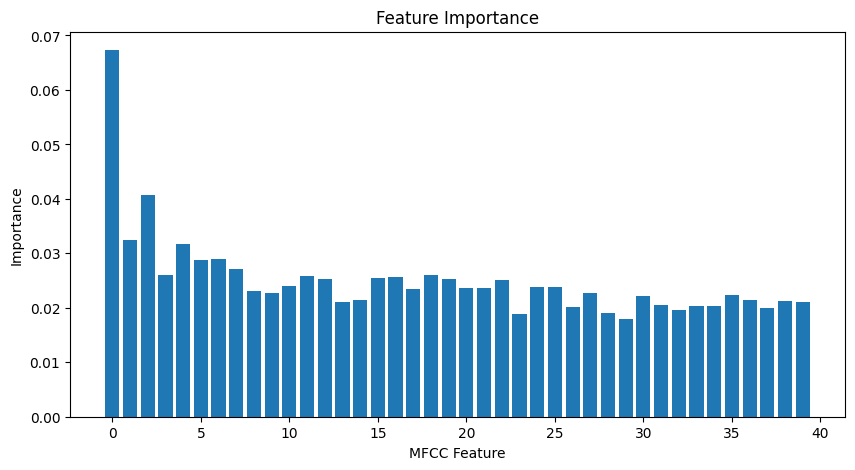

In [14]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)

plt.title("Feature Importance")
plt.xlabel("MFCC Feature")
plt.ylabel("Importance")

plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [18]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5902777777777778


In [19]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale')

In [20]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5902777777777778


In [22]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7152777777777778


In [25]:
svm_model = SVC(kernel='rbf', C=50, gamma=0.01)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.6805555555555556


In [26]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=100, gamma=0.01)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.6875


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=3)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 50, 'gamma': 0.01, 'kernel': 'rbf'}


In [28]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print("Best Accuracy:", accuracy_score(y_test, y_pred))

Best Accuracy: 0.6805555555555556


In [29]:
def extract_features(file):
    
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')
    
    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
    
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
    
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)
    
    spectral = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sample_rate).T, axis=0)
    
    return np.hstack([mfcc, chroma, mel, spectral])

In [30]:
def extract_features(file):
    
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')
    
    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
    
    # Chroma
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
    
    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)
    
    # Spectral Contrast
    spectral = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sample_rate).T, axis=0)
    
    return np.hstack([mfcc, chroma, mel, spectral])

In [31]:
def extract_features(file):
    
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')
    
    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
    
    # Chroma
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
    
    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)
    
    # Spectral Contrast
    spectral = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sample_rate).T, axis=0)
    
    return np.hstack([mfcc, chroma, mel, spectral])

In [32]:
features = []
labels = []

dataset_path = "../Dataset/archive (1)/audio_speech_actors_01-24"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("-")[2]

            data = extract_features(file_path)

            features.append(data)
            labels.append(emotion)

print("Total samples:", len(features))

Total samples: 1440


In [33]:
X = np.array(features)
y = np.array(labels)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=100, gamma=0.01)

svm_model.fit(X_train_scaled, y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.7048611111111112


In [40]:
def predict_emotion(file):

    feature = extract_features(file)

    feature = scaler.transform([feature])

    prediction = svm_model.predict(feature)

    emotion_dict = {
        "01": "Neutral",
        "02": "Calm",
        "03": "Happy",
        "04": "Sad",
        "05": "Angry",
        "06": "Fear",
        "07": "Disgust",
        "08": "Surprise"
    }

    print("Predicted Emotion:", emotion_dict[prediction[0]])

In [42]:
predict_emotion("test_audio.wav")

C:\Users\AIML-IEDC\AppData\Local\Temp\ipykernel_7564\2373488170.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file, res_type='kaiser_fast')


FileNotFoundError: [Errno 2] No such file or directory: 'test_audio.wav'

In [43]:
predict_emotion("../Dataset/archive (1)/audio_speech_actors_01-24/Actor_05/03-01-05-01-01-01-05.wav")

Predicted Emotion: Angry


In [44]:
predict_emotion("../Dataset/archive (1)/audio_speech_actors_01-24/Actor_05/03-01-05-01-01-01-05.wav")

Predicted Emotion: Angry


In [45]:
predict_emotion("../Dataset/archive (1)/audio_speech_actors_01-24/Actor_03/03-01-03-01-01-01-03.wav")

Predicted Emotion: Happy


In [46]:
!pip install sounddevice scipy

In [47]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 4   # seconds
fs = 44100     # sample rate

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("test_audio.wav", fs, recording)

print("Recording saved as test_audio.wav")

Speak now...
Recording saved as test_audio.wav


In [48]:
predict_emotion("test_audio.wav")

Predicted Emotion: Fear


In [49]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 4   # seconds
fs = 44100     # sample rate

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("test_audio.wav", fs, recording)

print("Recording saved as test_audio.wav")

Speak now...
Recording saved as test_audio.wav


In [50]:
predict_emotion("test_audio.wav")

Predicted Emotion: Fear


In [51]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 4   # seconds
fs = 44100     # sample rate

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("test_audio.wav", fs, recording)

print("Recording saved as test_audio.wav")

Speak now...
Recording saved as test_audio.wav


In [52]:
predict_emotion("test_audio.wav")

Predicted Emotion: Fear


In [53]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 4   # seconds
fs = 44100     # sample rate

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("test_audio.wav", fs, recording)

print("Recording saved as test_audio.wav")

Speak now...
Recording saved as test_audio.wav


In [54]:
predict_emotion("test_audio.wav")

Predicted Emotion: Fear


In [55]:
predict_emotion("../Dataset/archive (1)/audio_speech_actors_01-24/Actor_03/03-01-03-01-01-01-03.wav")

Predicted Emotion: Happy


In [56]:
audio = librosa.util.normalize(audio)

NameError: name 'audio' is not defined

In [57]:
def extract_features(file):

    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')
    
    # normalize audio
    audio = librosa.util.normalize(audio)

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)

    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)

    spectral = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sample_rate).T, axis=0)

    return np.hstack([mfcc, chroma, mel, spectral])

In [58]:
predict_emotion("test_audio.wav")

Predicted Emotion: Angry


In [59]:
predict_emotion("../Dataset/archive (1)/audio_speech_actors_01-24/Actor_03/03-01-03-01-01-01-03.wav")

Predicted Emotion: Angry


In [61]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 6
fs = 44100

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("my_voice.wav", fs, recording)

print("Recording saved as my_voice.wav")

Speak now...
Recording saved as my_voice.wav


In [62]:
predict_emotion("my_voice.wav")

Predicted Emotion: Angry


In [63]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 6
fs = 44100

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("my_voice.wav", fs, recording)

print("Recording saved as my_voice.wav")

Speak now...
Recording saved as my_voice.wav


In [64]:
predict_emotion("my_voice.wav")

Predicted Emotion: Angry


In [65]:
def extract_features(file):

    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')

    audio = librosa.util.normalize(audio)

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)
    spectral = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sample_rate).T, axis=0)

    return np.hstack((mfcc, chroma, mel, spectral))

In [66]:
import sounddevice as sd
from scipy.io.wavfile import write

duration = 6
fs = 44100

print("Speak now...")

recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

write("my_voice.wav", fs, recording)

print("Recording saved as my_voice.wav")

Speak now...
Recording saved as my_voice.wav


In [67]:
predict_emotion("my_voice.wav")

Predicted Emotion: Angry
